# Semiconductors vs Big Tech: SOXX and QQQ

This notebook studies whether semiconductors (`SOXX`) behave like a leveraged version of large-cap tech (`QQQ`) over the last five years.

Core questions:

- how similar are their return paths and risk profiles?
- does `SOXX` amplify `QQQ` in bullish AI-driven regimes?
- can a simple rotation rule improve on just holding `QQQ`?


In [9]:
# Bootstrap: install missing packages into the active notebook kernel.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "yfinance": "yfinance",
    "arch": "arch",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages into this notebook kernel:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already installed in this notebook kernel.")

print("Kernel Python:", sys.executable)


All required packages are already installed in this notebook kernel.
Kernel Python: /Users/akshit/Code/IC Quant Project/.venv/bin/python


In [10]:
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

from arch import arch_model
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# -----------------------------
# Config
# -----------------------------
TICKERS: List[str] = ["SOXX", "QQQ"]
LEVERAGED_TICKER = "SOXX"
BASE_TICKER = "QQQ"
END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=5)
ROLLING_WINDOW = 30
RELATIVE_STRENGTH_WINDOW = 50
TREND_FILTER_WINDOW = 50
TRADING_DAYS_PER_YEAR = 252
RIDGE_ALPHA = 1.0
LASSO_ALPHA = 0.0005

BASE_DIR = Path.cwd()
EXPORT_DIR = BASE_DIR / "outputs"
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Tickers: {TICKERS}")
print(f"Start date: {START_DATE.date()}")
print(f"End date: {END_DATE.date()}")
print(f"Rolling window: {ROLLING_WINDOW} trading days")
print(f"Trend filter window: {TREND_FILTER_WINDOW} trading days")


Tickers: ['SOXX', 'QQQ']
Start date: 2021-04-22
End date: 2026-04-22
Rolling window: 30 trading days


## Data Choices

- Returns and risk metrics use `Adj Close`.
- Missing values are audited first, then forward-filled conservatively.
- The notebook uses the same cleaning logic as the earlier project for consistency.


In [11]:
# -----------------------------
# Data loading and preprocessing
# -----------------------------
def fetch_data(tickers: List[str], start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    df = yf.download(
        tickers=tickers,
        start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=False,
        progress=False,
        group_by="column",
    )
    if df.empty:
        raise ValueError("No data returned. Check ticker symbols or internet connectivity.")
    return df.sort_index()


def extract_field(raw_df: pd.DataFrame, field: str) -> pd.DataFrame:
    extracted = raw_df[field].copy() if isinstance(raw_df.columns, pd.MultiIndex) else raw_df[[field]].copy()
    if isinstance(extracted, pd.Series):
        extracted = extracted.to_frame(name=TICKERS[0])
    return extracted.sort_index()


def audit_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "first_valid": df.apply(pd.Series.first_valid_index),
        "last_valid": df.apply(pd.Series.last_valid_index),
    }).sort_values("missing_count", ascending=False)


def clean_price_data(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.sort_index().ffill().dropna(how="all")


def calculate_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()


def normalize_prices(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.div(prices.iloc[0]).mul(100)


raw_data = fetch_data(TICKERS, START_DATE, END_DATE)
adj_close_raw = extract_field(raw_data, "Adj Close")
missing_audit = audit_missing_values(adj_close_raw)
adj_close = clean_price_data(adj_close_raw)
returns = calculate_returns(adj_close)
normalized_prices = normalize_prices(adj_close)

display(missing_audit)
display(adj_close.tail())
display(returns.tail())


,missing_count,missing_pct,first_valid,last_valid
Ticker,,,,
QQQ,0,0.0000,2021-04-22,2026-04-22
SOXX,0,0.0000,2021-04-22,2026-04-22


Ticker,QQQ,SOXX
Date,,
2026-04-16,640.4700,405.9500
2026-04-17,648.8500,415.7100
2026-04-20,646.7900,417.5500
2026-04-21,644.3300,420.7000
2026-04-22,655.1100,431.7700


Ticker,QQQ,SOXX
Date,,
2026-04-16,0.0048,0.0102
2026-04-17,0.0131,0.0240
2026-04-20,-0.0032,0.0044
2026-04-21,-0.0038,0.0075
2026-04-22,0.0167,0.0263


## Concepts

- **GARCH** stands for *Generalized Autoregressive Conditional Heteroskedasticity*. Plain English: it models how volatility changes over time instead of assuming volatility is constant.
- **TSS** means *Total Sum of Squares*: total variation in the target series.
- **RSS** means *Residual Sum of Squares*: variation left unexplained by the model.
- **Ridge regularization** shrinks coefficients toward zero but usually keeps all features.
- **Lasso regularization** can shrink some coefficients all the way to zero, which acts like feature selection.


In [ ]:
# -----------------------------
# Statistics and modeling
# -----------------------------
def annualize_return(daily_returns: pd.Series) -> float:
    compounded = (1 + daily_returns).prod()
    periods = daily_returns.shape[0]
    return compounded ** (TRADING_DAYS_PER_YEAR / periods) - 1 if periods > 0 else np.nan


def annualize_volatility(daily_returns: pd.Series) -> float:
    return daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)


def calculate_max_drawdown(daily_returns: pd.Series) -> float:
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative.div(running_max) - 1
    return drawdown.min()


def get_summary_stats(returns_df: pd.DataFrame) -> pd.DataFrame:
    rows = {}
    for ticker in returns_df.columns:
        series = returns_df[ticker].dropna()
        rows[ticker] = {
            "annual_return": annualize_return(series),
            "annual_volatility": annualize_volatility(series),
            "max_drawdown": calculate_max_drawdown(series),
            "average_daily_return": series.mean(),
            "daily_volatility": series.std(),
        }
    return pd.DataFrame(rows).T.sort_values("annual_return", ascending=False)


def get_rolling_volatility(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    return returns_df.rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)


def get_rolling_correlation(returns_df: pd.DataFrame, left: str, right: str, window: int) -> pd.Series:
    return returns_df[left].rolling(window).corr(returns_df[right]).rename(f"{left}_vs_{right}")


def fit_pair_regression(returns_df: pd.DataFrame, y_ticker: str, x_ticker: str):
    aligned = returns_df[[y_ticker, x_ticker]].dropna().copy()
    X = sm.add_constant(aligned[x_ticker])
    model = sm.OLS(aligned[y_ticker], X).fit()
    fitted = model.predict(X)
    residuals = aligned[y_ticker] - fitted
    tss = ((aligned[y_ticker] - aligned[y_ticker].mean()) ** 2).sum()
    rss = (residuals ** 2).sum()
    metrics = pd.Series({
        "beta": model.params[x_ticker],
        "alpha": model.params["const"],
        "correlation": aligned[y_ticker].corr(aligned[x_ticker]),
        "r_squared": model.rsquared,
        "rss": rss,
        "tss": tss,
        "rss_to_tss": rss / tss if tss else np.nan,
    })
    return model, metrics, residuals


def fit_garch_volatility(returns_series: pd.Series) -> pd.Series:
    clean = (returns_series.dropna() * 100).astype(float)
    model = arch_model(clean, mean="Zero", vol="GARCH", p=1, q=1, rescale=False)
    fitted = model.fit(disp="off")
    conditional_vol = fitted.conditional_volatility / 100 * np.sqrt(TRADING_DAYS_PER_YEAR)
    conditional_vol.name = returns_series.name
    return conditional_vol


def build_predictive_features(returns_df: pd.DataFrame, rolling_vol_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = pd.DataFrame(index=returns_df.index)
    feature_df["qqq_ret_0"] = returns_df[BASE_TICKER]
    feature_df["qqq_ret_lag1"] = returns_df[BASE_TICKER].shift(1)
    feature_df["qqq_ret_lag2"] = returns_df[BASE_TICKER].shift(2)
    feature_df["soxx_ret_lag1"] = returns_df[LEVERAGED_TICKER].shift(1)
    feature_df["vol_spread"] = rolling_vol_df[LEVERAGED_TICKER] - rolling_vol_df[BASE_TICKER]
    feature_df["target_next_soxx_return"] = returns_df[LEVERAGED_TICKER].shift(-1)
    return feature_df.dropna()


def compare_regularized_models(feature_df: pd.DataFrame) -> pd.DataFrame:
    split_idx = int(len(feature_df) * 0.8)
    train = feature_df.iloc[:split_idx]
    test = feature_df.iloc[split_idx:]

    X_train = train.drop(columns="target_next_soxx_return")
    y_train = train["target_next_soxx_return"]
    X_test = test.drop(columns="target_next_soxx_return")
    y_test = test["target_next_soxx_return"]

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=RIDGE_ALPHA),
        "Lasso": Lasso(alpha=LASSO_ALPHA, max_iter=10000),
    }

    rows = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        test_tss = ((y_test - y_test.mean()) ** 2).sum()
        test_rss = ((y_test - preds) ** 2).sum()
        rows[name] = {
            "test_mse": mean_squared_error(y_test, preds),
            "test_rss": test_rss,
            "test_tss": test_tss,
            "test_r_squared": 1 - test_rss / test_tss if test_tss else np.nan,
        }
    return pd.DataFrame(rows).T.sort_values("test_mse")


def backtest_semis_amplification_strategy(
    returns_df: pd.DataFrame,
    prices_df: pd.DataFrame,
    rolling_vol_df: pd.DataFrame,
    base_ticker: str,
    leveraged_ticker: str,
    momentum_window: int,
    relative_strength_window: int,
) -> Tuple[pd.Series, pd.DataFrame]:
    qqq_momentum = prices_df[base_ticker].pct_change(momentum_window)
    relative_strength = prices_df[leveraged_ticker] / prices_df[base_ticker]
    relative_strength_ma = relative_strength.rolling(relative_strength_window).mean()

    strategy_returns = []
    decision_log = []
    valid_dates = list(returns_df.index)

    for idx in range(max(momentum_window, relative_strength_window), len(valid_dates) - 1):
        signal_date = valid_dates[idx]
        trade_date = valid_dates[idx + 1]

        signal_is_on = (
            (qqq_momentum.loc[signal_date] > 0)
            and (relative_strength.loc[signal_date] > relative_strength_ma.loc[signal_date])
            and (rolling_vol_df.loc[signal_date, leveraged_ticker] <= 1.35 * rolling_vol_df.loc[signal_date, base_ticker])
        )

        chosen_asset = leveraged_ticker if signal_is_on else base_ticker
        signal_state = "Hold SOXX" if signal_is_on else "Hold QQQ"

        strategy_returns.append(pd.Series({"date": trade_date, "strategy_return": returns_df.loc[trade_date, chosen_asset]}))
        decision_log.append(pd.Series({
            "date": trade_date,
            "signal_date": signal_date,
            "qqq_momentum": qqq_momentum.loc[signal_date],
            "relative_strength_gap": relative_strength.loc[signal_date] - relative_strength_ma.loc[signal_date],
            "signal_state": signal_state,
            "chosen_asset": chosen_asset,
        }))

    strategy_series = pd.DataFrame(strategy_returns).set_index("date")["strategy_return"]
    decisions_df = pd.DataFrame(decision_log).set_index("date")
    benchmark = returns_df[base_ticker].rename("benchmark_return")
    combined = pd.concat([strategy_series, benchmark, decisions_df], axis=1).dropna(subset=["strategy_return", "benchmark_return"])
    return combined["strategy_return"], combined


def backtest_stat_arb_mean_reversion(
    returns_df: pd.DataFrame,
    prices_df: pd.DataFrame,
    base_ticker: str,
    leveraged_ticker: str,
    window: int,
    z_threshold: float = 1.5,
) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Capitalizes on the high correlation and volatility spread.
    Trades the relative price ratio: when SOXX gets too cheap vs QQQ (z_score < -threshold), buy SOXX.
    When SOXX gets too expensive (z_score > threshold), rotate back to QQQ.
    """
    ratio = prices_df[leveraged_ticker] / prices_df[base_ticker]
    rolling_mean = ratio.rolling(window).mean()
    rolling_std = ratio.rolling(window).std()
    z_score = (ratio - rolling_mean) / rolling_std

    strategy_returns = []
    decision_log = []
    valid_dates = list(returns_df.index)

    for idx in range(window, len(valid_dates) - 1):
        signal_date = valid_dates[idx]
        trade_date = valid_dates[idx + 1]

        current_z = z_score.loc[signal_date]

        if pd.isna(current_z):
            chosen_asset = base_ticker
            signal_state = "Hold QQQ (Initializing)"
        elif current_z < -z_threshold:
            chosen_asset = leveraged_ticker
            signal_state = "Mean Reversion (Buy SOXX)"
        elif current_z > z_threshold:
            chosen_asset = base_ticker
            signal_state = "Mean Reversion (Buy QQQ)"
        else:
            chosen_asset = base_ticker
            signal_state = "Hold QQQ"

        strategy_returns.append(pd.Series({"date": trade_date, "strategy_return": returns_df.loc[trade_date, chosen_asset]}))
        decision_log.append(pd.Series({
            "date": trade_date,
            "signal_date": signal_date,
            "z_score": current_z,
            "signal_state": signal_state,
            "chosen_asset": chosen_asset,
        }))

    strategy_series = pd.DataFrame(strategy_returns).set_index("date")["strategy_return"]
    decisions_df = pd.DataFrame(decision_log).set_index("date")
    benchmark = returns_df[base_ticker].rename("benchmark_return")
    combined = pd.concat([strategy_series, benchmark, decisions_df], axis=1).dropna(subset=["strategy_return", "benchmark_return"])
    return combined["strategy_return"], combined


def backtest_stat_arb_with_trend_filter(
    returns_df: pd.DataFrame,
    prices_df: pd.DataFrame,
    base_ticker: str,
    leveraged_ticker: str,
    window: int,
    trend_filter_window: int,
    z_threshold: float = 1.5,
) -> Tuple[pd.Series, pd.DataFrame]:
    ratio = prices_df[leveraged_ticker] / prices_df[base_ticker]
    rolling_mean = ratio.rolling(window).mean()
    rolling_std = ratio.rolling(window).std()
    z_score = (ratio - rolling_mean) / rolling_std
    qqq_trend_ma = prices_df[base_ticker].rolling(trend_filter_window).mean()
    qqq_trend_gap = prices_df[base_ticker] - qqq_trend_ma

    strategy_returns = []
    decision_log = []
    valid_dates = list(returns_df.index)
    start_idx = max(window, trend_filter_window)

    for idx in range(start_idx, len(valid_dates) - 1):
        signal_date = valid_dates[idx]
        trade_date = valid_dates[idx + 1]

        current_z = z_score.loc[signal_date]
        trend_gap = qqq_trend_gap.loc[signal_date]
        trend_is_positive = trend_gap > 0
        trend_is_negative = trend_gap < 0

        if pd.isna(current_z):
            chosen_asset = base_ticker
            strategy_return = returns_df.loc[trade_date, base_ticker]
            signal_state = "Hold QQQ (Initializing)"
        elif (current_z < -z_threshold) and trend_is_positive:
            chosen_asset = leveraged_ticker
            strategy_return = returns_df.loc[trade_date, leveraged_ticker]
            signal_state = "Filtered Reversion (Buy SOXX)"
        elif (current_z > z_threshold) and trend_is_negative:
            chosen_asset = f"SHORT {leveraged_ticker}"
            strategy_return = -returns_df.loc[trade_date, leveraged_ticker]
            signal_state = "Filtered Reversion (Short SOXX)"
        else:
            chosen_asset = base_ticker
            strategy_return = returns_df.loc[trade_date, base_ticker]
            signal_state = "Hold QQQ"

        strategy_returns.append(pd.Series({"date": trade_date, "strategy_return": strategy_return}))
        decision_log.append(pd.Series({
            "date": trade_date,
            "signal_date": signal_date,
            "z_score": current_z,
            "qqq_trend_gap": trend_gap,
            "trend_is_positive": trend_is_positive,
            "trend_is_negative": trend_is_negative,
            "signal_state": signal_state,
            "chosen_asset": chosen_asset,
        }))

    strategy_series = pd.DataFrame(strategy_returns).set_index("date")["strategy_return"]
    decisions_df = pd.DataFrame(decision_log).set_index("date")
    benchmark = returns_df[base_ticker].rename("benchmark_return")
    combined = pd.concat([strategy_series, benchmark, decisions_df], axis=1).dropna(subset=["strategy_return", "benchmark_return"])
    return combined["strategy_return"], combined


summary_stats = get_summary_stats(returns)
rolling_vol = get_rolling_volatility(returns, ROLLING_WINDOW)
rolling_corr = get_rolling_correlation(returns, LEVERAGED_TICKER, BASE_TICKER, ROLLING_WINDOW)
pair_model, pair_metrics, pair_residuals = fit_pair_regression(returns, LEVERAGED_TICKER, BASE_TICKER)
garch_vol = pd.concat([
    fit_garch_volatility(returns[LEVERAGED_TICKER]),
    fit_garch_volatility(returns[BASE_TICKER]),
], axis=1)
feature_df = build_predictive_features(returns, rolling_vol)
regularization_results = compare_regularized_models(feature_df)

strategy_returns, strategy_log = backtest_semis_amplification_strategy(
    returns,
    adj_close,
    rolling_vol,
    BASE_TICKER,
    LEVERAGED_TICKER,
    ROLLING_WINDOW,
    RELATIVE_STRENGTH_WINDOW,
)

stat_arb_returns, stat_arb_log = backtest_stat_arb_mean_reversion(
    returns,
    adj_close,
    BASE_TICKER,
    LEVERAGED_TICKER,
    ROLLING_WINDOW,
    z_threshold=1.5,
)

filtered_stat_arb_returns, filtered_stat_arb_log = backtest_stat_arb_with_trend_filter(
    returns,
    adj_close,
    BASE_TICKER,
    LEVERAGED_TICKER,
    ROLLING_WINDOW,
    TREND_FILTER_WINDOW,
    z_threshold=1.5,
)

strategy_comparison = pd.DataFrame({
    "Semis Amplification Strategy": (1 + strategy_returns).cumprod(),
    BASE_TICKER: (1 + returns[BASE_TICKER].loc[strategy_returns.index]).cumprod(),
})
strategy_summary = pd.DataFrame({
    "annual_return": {
        "Semis Amplification Strategy": annualize_return(strategy_returns),
        BASE_TICKER: annualize_return(returns[BASE_TICKER].loc[strategy_returns.index]),
    },
    "annual_volatility": {
        "Semis Amplification Strategy": annualize_volatility(strategy_returns),
        BASE_TICKER: annualize_volatility(returns[BASE_TICKER].loc[strategy_returns.index]),
    },
    "max_drawdown": {
        "Semis Amplification Strategy": calculate_max_drawdown(strategy_returns),
        BASE_TICKER: calculate_max_drawdown(returns[BASE_TICKER].loc[strategy_returns.index]),
    },
})

stat_arb_comparison = pd.DataFrame({
    "Stat Arb Reversion Strategy": (1 + stat_arb_returns).cumprod(),
    BASE_TICKER: (1 + returns[BASE_TICKER].loc[stat_arb_returns.index]).cumprod(),
})
stat_arb_summary = pd.DataFrame({
    "annual_return": {
        "Stat Arb Reversion Strategy": annualize_return(stat_arb_returns),
        BASE_TICKER: annualize_return(returns[BASE_TICKER].loc[stat_arb_returns.index]),
    },
    "annual_volatility": {
        "Stat Arb Reversion Strategy": annualize_volatility(stat_arb_returns),
        BASE_TICKER: annualize_volatility(returns[BASE_TICKER].loc[stat_arb_returns.index]),
    },
    "max_drawdown": {
        "Stat Arb Reversion Strategy": calculate_max_drawdown(stat_arb_returns),
        BASE_TICKER: calculate_max_drawdown(returns[BASE_TICKER].loc[stat_arb_returns.index]),
    },
})

filtered_stat_arb_comparison = pd.DataFrame({
    "Filtered Stat Arb Long/Short Strategy": (1 + filtered_stat_arb_returns).cumprod(),
    BASE_TICKER: (1 + returns[BASE_TICKER].loc[filtered_stat_arb_returns.index]).cumprod(),
})
filtered_stat_arb_summary = pd.DataFrame({
    "annual_return": {
        "Filtered Stat Arb Long/Short Strategy": annualize_return(filtered_stat_arb_returns),
        BASE_TICKER: annualize_return(returns[BASE_TICKER].loc[filtered_stat_arb_returns.index]),
    },
    "annual_volatility": {
        "Filtered Stat Arb Long/Short Strategy": annualize_volatility(filtered_stat_arb_returns),
        BASE_TICKER: annualize_volatility(returns[BASE_TICKER].loc[filtered_stat_arb_returns.index]),
    },
    "max_drawdown": {
        "Filtered Stat Arb Long/Short Strategy": calculate_max_drawdown(filtered_stat_arb_returns),
        BASE_TICKER: calculate_max_drawdown(returns[BASE_TICKER].loc[filtered_stat_arb_returns.index]),
    },
})

all_strategy_summary = pd.DataFrame({
    "annual_return": {
        "Semis Amplification Strategy": annualize_return(strategy_returns),
        "Stat Arb Reversion Strategy": annualize_return(stat_arb_returns),
        "Filtered Stat Arb Long/Short Strategy": annualize_return(filtered_stat_arb_returns),
        BASE_TICKER: annualize_return(returns[BASE_TICKER]),
    },
    "annual_volatility": {
        "Semis Amplification Strategy": annualize_volatility(strategy_returns),
        "Stat Arb Reversion Strategy": annualize_volatility(stat_arb_returns),
        "Filtered Stat Arb Long/Short Strategy": annualize_volatility(filtered_stat_arb_returns),
        BASE_TICKER: annualize_volatility(returns[BASE_TICKER]),
    },
    "max_drawdown": {
        "Semis Amplification Strategy": calculate_max_drawdown(strategy_returns),
        "Stat Arb Reversion Strategy": calculate_max_drawdown(stat_arb_returns),
        "Filtered Stat Arb Long/Short Strategy": calculate_max_drawdown(filtered_stat_arb_returns),
        BASE_TICKER: calculate_max_drawdown(returns[BASE_TICKER]),
    },
})

display(summary_stats)
display(pair_metrics.to_frame(name="value"))
display(regularization_results)
display(all_strategy_summary)


,annual_return,annual_volatility,max_drawdown,average_daily_return,daily_volatility
SOXX,0.2606,0.3559,-0.4575,0.0012,0.0224
QQQ,0.1509,0.2241,-0.3512,0.0007,0.0141


,value
beta,1.4057
alpha,0.0002
correlation,0.8852
r_squared,0.7835
rss,0.1364
tss,0.6302
rss_to_tss,0.2165


,test_mse,test_rss,test_tss,test_r_squared
Lasso,0.0004,0.1020,0.0995,-0.0250
Ridge,0.0004,0.1028,0.0995,-0.0330
OLS,0.0004,0.1037,0.0995,-0.0423


,annual_return,annual_volatility,max_drawdown
Semis Amplification Strategy,0.1387,0.2270,-0.3675
Stat Arb Reversion Strategy,0.1703,0.2579,-0.3994
QQQ,0.1402,0.2266,-0.3512


## Section 1: Core Pair Analysis

This section answers the descriptive question first: did semiconductors actually behave like a higher-beta version of large-cap tech over this sample?


In [13]:
# -----------------------------
# Visualization helpers
# -----------------------------
def plot_normalized_prices(prices_df: pd.DataFrame):
    ax = normalize_prices(prices_df).plot(linewidth=2)
    ax.set_title("Normalized Price Performance (Base = 100)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_rolling_volatility(rolling_vol_df: pd.DataFrame, window: int):
    ax = rolling_vol_df.plot(linewidth=2)
    ax.set_title(f"{window}-Day Rolling Annualized Volatility")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualized Volatility")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_rolling_correlation(rolling_corr_series: pd.Series, window: int):
    ax = rolling_corr_series.plot(linewidth=2, color="#2a6f97")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{window}-Day Rolling Correlation: {LEVERAGED_TICKER} vs {BASE_TICKER}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Correlation")
    plt.tight_layout()
    return ax


def plot_return_distributions(returns_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, ticker in zip(axes, returns_df.columns):
        sns.histplot(returns_df[ticker], kde=True, bins=40, ax=ax, color="#2a6f97")
        ax.set_title(f"Return Distribution: {ticker}")
        ax.set_xlabel("Daily Return")
    plt.tight_layout()
    return axes


def plot_garch_volatility(garch_vol_df: pd.DataFrame):
    ax = garch_vol_df.plot(linewidth=2)
    ax.set_title("GARCH(1,1) Conditional Annualized Volatility")
    ax.set_xlabel("Date")
    ax.set_ylabel("Conditional Volatility")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


def plot_strategy_comparison(strategy_df: pd.DataFrame, title: str):
    indexed = strategy_df.div(strategy_df.iloc[0]).mul(100)
    ax = indexed.plot(linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value")
    ax.legend(title="Series")
    plt.tight_layout()
    return ax


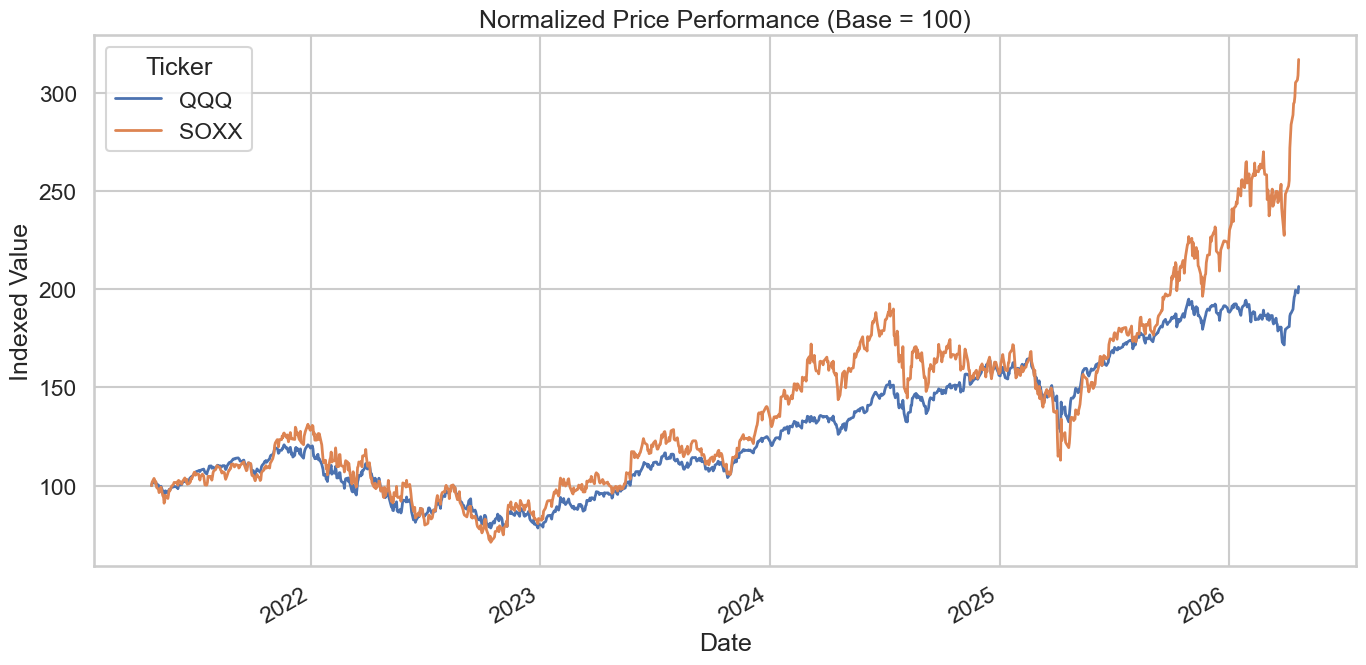

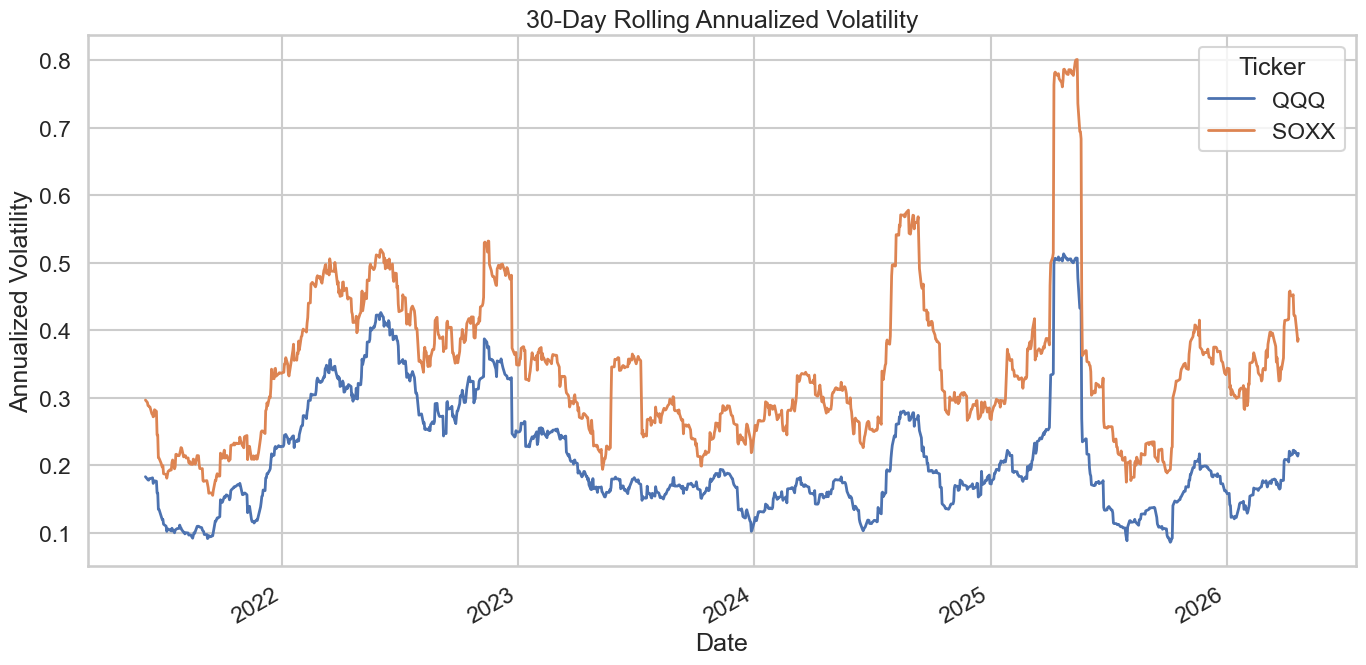

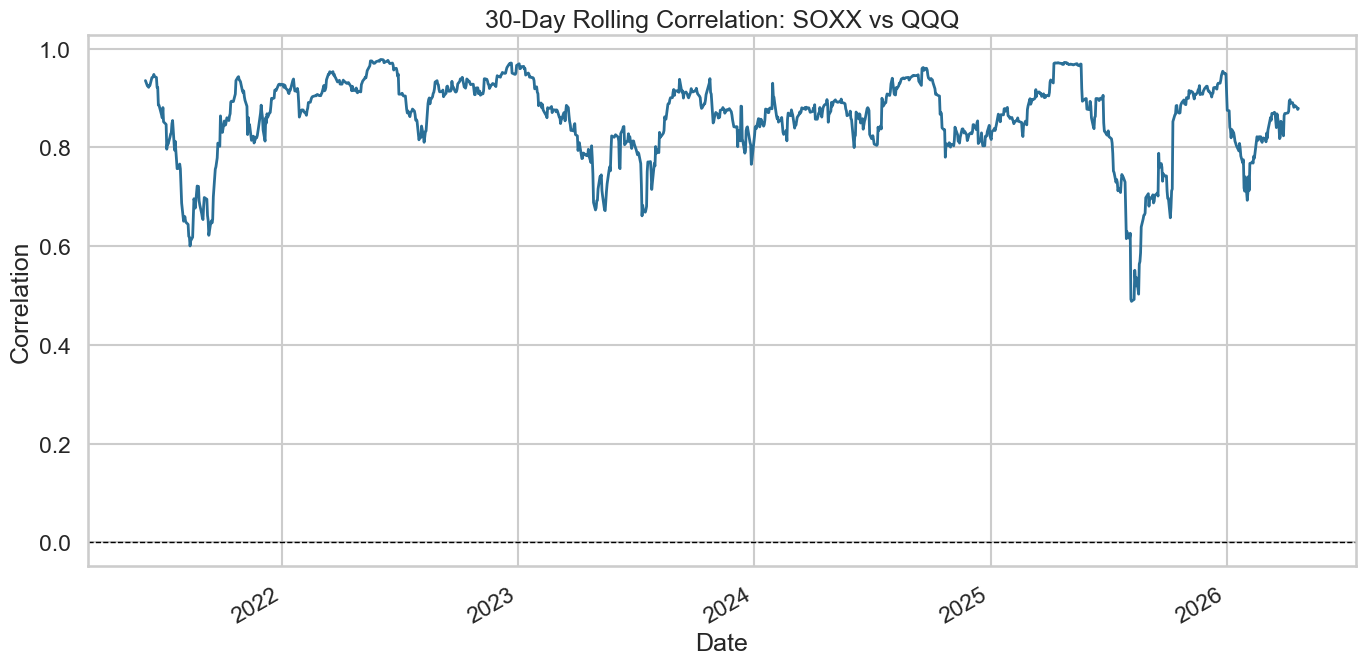

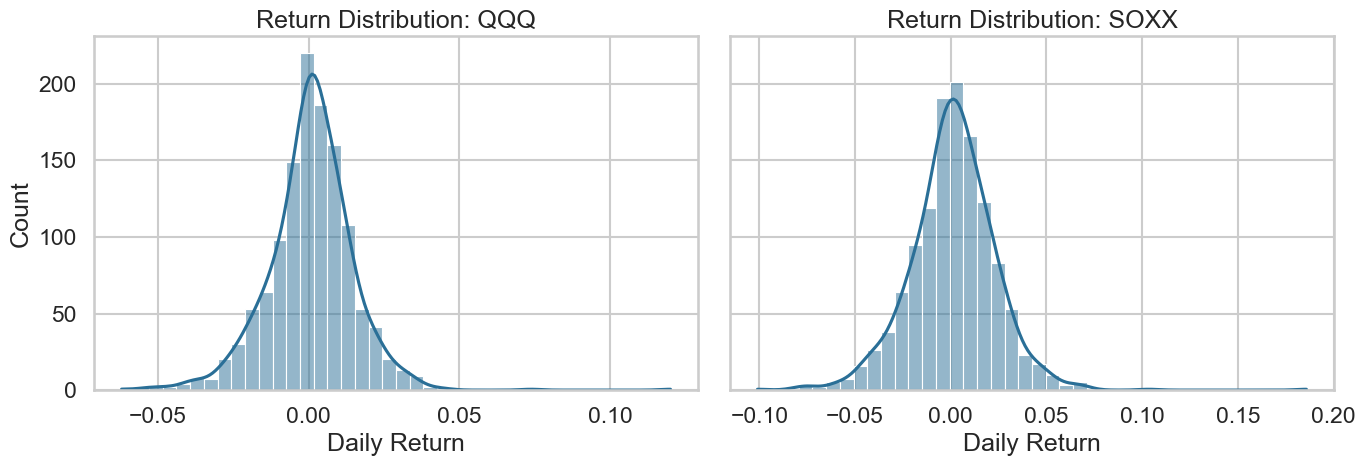

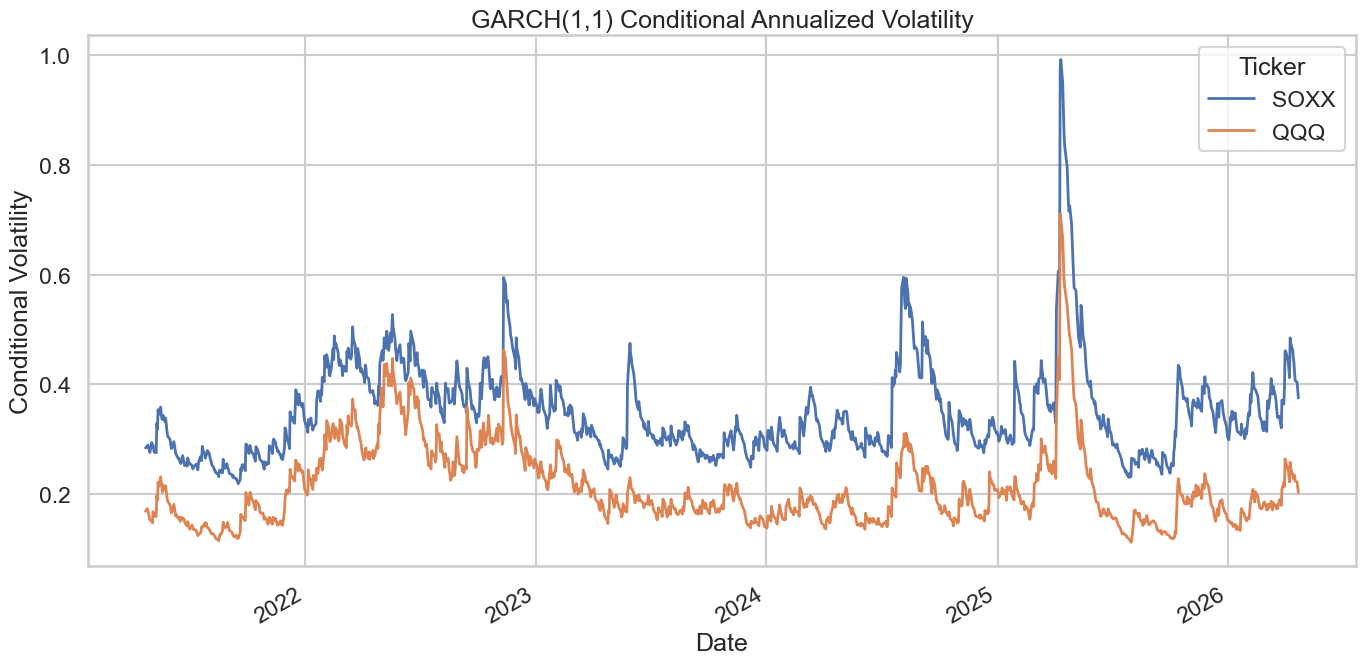

In [14]:
plot_normalized_prices(adj_close)
plt.show()

plot_rolling_volatility(rolling_vol, ROLLING_WINDOW)
plt.show()

plot_rolling_correlation(rolling_corr, ROLLING_WINDOW)
plt.show()

plot_return_distributions(returns)
plt.show()

plot_garch_volatility(garch_vol)
plt.show()


## Section 2: Regression Diagnostics

This section separates descriptive pair behavior from predictive modeling:

- the simple pair regression gives beta, RSS, TSS, and `R^2`
- the OLS/Ridge/Lasso comparison uses a small lagged feature set to predict next-day `SOXX` returns


In [15]:
display(pair_metrics.to_frame(name="value"))
display(regularization_results)


,value
beta,1.4057
alpha,0.0002
correlation,0.8852
r_squared,0.7835
rss,0.1364
tss,0.6302
rss_to_tss,0.2165


,test_mse,test_rss,test_tss,test_r_squared
Lasso,0.0004,0.1020,0.0995,-0.0250
Ridge,0.0004,0.1028,0.0995,-0.0330
OLS,0.0004,0.1037,0.0995,-0.0423


## Section 3: Semis Amplification Strategy

Strategy idea:

- stay in `QQQ` by default
- only rotate into `SOXX` when `QQQ` 30-day momentum is positive
- require `SOXX / QQQ` relative strength to be above its 50-day moving average
- avoid chasing `SOXX` if its rolling volatility is far above `QQQ`

Interpretation: this tries to use semiconductors as the higher-conviction, higher-beta expression of a strong tech regime instead of holding semis all the time.


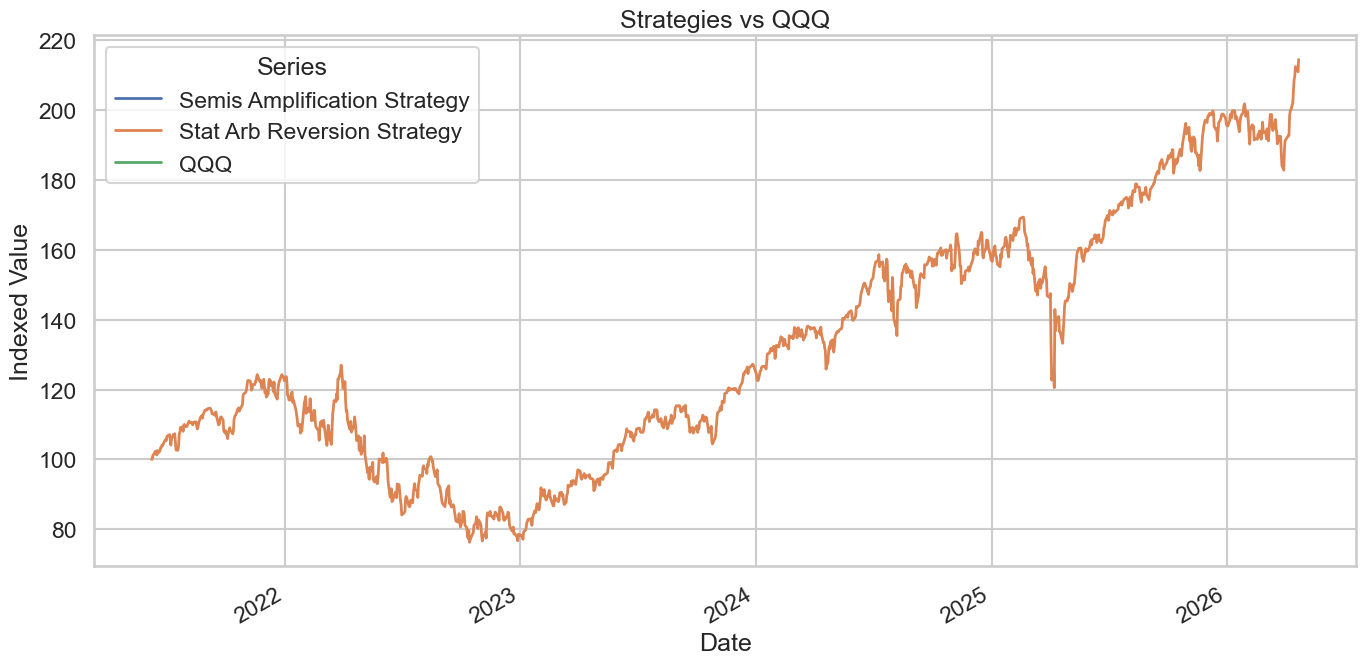

,annual_return,annual_volatility,max_drawdown
Semis Amplification Strategy,0.1387,0.2270,-0.3675
Stat Arb Reversion Strategy,0.1703,0.2579,-0.3994
QQQ,0.1402,0.2266,-0.3512



--- Stat Arb / Mean Reversion Log ---


,strategy_return,benchmark_return,signal_date,z_score,signal_state,chosen_asset
2021-06-08,0.0005,0.0005,2021-06-07,0.9455,Hold QQQ,QQQ
2021-06-09,0.0002,0.0002,2021-06-08,0.6357,Hold QQQ,QQQ
2021-06-10,0.0104,0.0104,2021-06-09,0.3796,Hold QQQ,QQQ
2021-06-11,0.0026,0.0026,2021-06-10,0.4334,Hold QQQ,QQQ
2021-06-14,0.0096,0.0096,2021-06-11,0.5634,Hold QQQ,QQQ
2021-06-15,-0.0065,-0.0065,2021-06-14,0.7639,Hold QQQ,QQQ
2021-06-16,-0.0037,-0.0037,2021-06-15,0.6224,Hold QQQ,QQQ
2021-06-17,0.0127,0.0127,2021-06-16,0.2605,Hold QQQ,QQQ
2021-06-18,-0.0078,-0.0078,2021-06-17,0.1304,Hold QQQ,QQQ
2021-06-21,0.0062,0.0062,2021-06-18,-0.7771,Hold QQQ,QQQ



--- Semis Amplification Log ---


,strategy_return,benchmark_return,signal_date,qqq_momentum,relative_strength_gap,signal_state,chosen_asset
2021-07-07,0.0021,0.0021,2021-07-06,0.1027,-0.0058,Hold QQQ,QQQ
2021-07-08,-0.0060,-0.0060,2021-07-07,0.0868,-0.0124,Hold QQQ,QQQ
2021-07-09,0.0062,0.0062,2021-07-08,0.0787,-0.0147,Hold QQQ,QQQ
2021-07-12,0.0039,0.0039,2021-07-09,0.0817,-0.0105,Hold QQQ,QQQ
2021-07-13,0.0000,0.0000,2021-07-12,0.0900,-0.0066,Hold QQQ,QQQ
2021-07-14,0.0018,0.0018,2021-07-13,0.0866,-0.0082,Hold QQQ,QQQ
2021-07-15,-0.0070,-0.0070,2021-07-14,0.0922,-0.0107,Hold QQQ,QQQ
2021-07-16,-0.0081,-0.0081,2021-07-15,0.0824,-0.0167,Hold QQQ,QQQ
2021-07-19,-0.0082,-0.0082,2021-07-16,0.0849,-0.0217,Hold QQQ,QQQ
2021-07-20,0.0116,0.0116,2021-07-19,0.0580,-0.0185,Hold QQQ,QQQ


In [ ]:
plot_strategy_comparison(strategy_comparison, "Semis Amplification Strategy vs QQQ")
plt.show()

display(strategy_summary)
display(strategy_log.head(10))


## Section 4: Mean-Reversion (Pairs Trade) Strategy

Capitalizes on the observation that `SOXX` acts as an amplified `QQQ`. It calculates a rolling Z-score on the `SOXX/QQQ` price ratio. When `SOXX` becomes overly cheap vs `QQQ` (Z-score < -1.5), it rotates into `SOXX`. When it gets too rich (Z > 1.5), it rotates back to `QQQ`.


In [ ]:
plot_strategy_comparison(stat_arb_comparison, "Stat Arb Mean Reversion vs QQQ")
plt.show()

display(stat_arb_summary)
display(stat_arb_log.head(10))


## Section 5: Mean Reversion With QQQ Trend Filter and Short Side

This version keeps the same `SOXX / QQQ` Z-score signal but adds a regime filter and an asymmetric short side:

- buy the `SOXX` dip when the spread says it is cheap **and** `QQQ` is still above its 50-day moving average
- short `SOXX` when the spread says it is rich **and** `QQQ` is below its 50-day moving average
- otherwise stay in `QQQ`

Interpretation: avoid fading semiconductors during broad tech breakdowns, but also exploit overpriced semis when the broader big-tech regime is weak.


In [ ]:
plot_strategy_comparison(filtered_stat_arb_comparison, "Filtered Stat Arb Long/Short vs QQQ")
plt.show()

display(filtered_stat_arb_summary)
display(filtered_stat_arb_log.head(10))
